# **Data Driven Models**

# Linear Regression

### Last Class
- Modelling Assignment 2

### Goals for Today
- Define linear regression for both a single input and multiple inputs in a mathematical model
- Apply a linear regression method to a mathematical models

### Pre-Lecture Activities

- [Course notes](https://ubcmath.github.io/MATH360/data-driven/linear-regression/index.html): Linear regression, including the sections on Least Squares, Residuals, and Regression packages

In [1]:
#import packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
%matplotlib inline


print("packages imported")

packages imported


### Service Call Example
Suppose we want to study the relationship between the length of a service call in minutes ($Y$) and the number of electrical components needed to be repaired or replaced ($X$).  Calculate the least squares regression line.

Calculate the coefficients in the linear regression $Y = \hat{\beta}_0 + \hat{\beta}_1 X$ using the data set:

Data: 

$x = [1,3,4,6,9,10]$

$y = [23,49,74,96,149,160]$.

You can use the fact that 

$\beta_1 = \frac{S_{xy}}{S_{xx}}$

$\beta_0 = \bar{y} - \beta_1 \bar{x},$

where $\bar{x}$ is the mean of the $x$ values, $\bar{y}$ is the mean of the $y$ values, $S_{xy}=\sum\limits_i (y_i-\bar{y})(x_i-\bar{x})$, and $S_{xx} = \sum\limits_i (x_i - \bar{x})^2.$

Recall: np.mean will calculate the mean of your data and that np.sum will sum across a vector.

Make a plot of the data with your line of best fit.

In [2]:
from sklearn import linear_model

x = [1,3,4,6,9,10]
y = [23,49,74,96,149,160]

# sklearn wants the vectors as columns so (x, 1)
xr = np.array(x).reshape(-1,1)
yr = np.array(y).reshape(-1,1)

reg_ols = linear_model.LinearRegression().fit(xr, yr)

In [7]:
print(f'b0: {reg_ols.intercept_}, b1: {reg_ols.coef_}')

b0: [6.6504065], b1: [[15.48780488]]


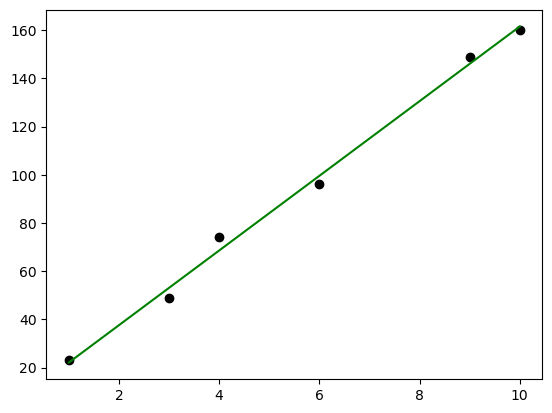

In [8]:
yp = reg_ols.predict(xr)
plt.scatter(x, y, color='black', marker='o')
plt.plot(x, yp, color='green')

In [9]:
beta1, beta0, r, p , std_err = stats.linregress(x,y)
print(f'b0: {beta0}, b1: {beta1}')

b0: 6.650406504065032, b1: 15.487804878048781


In [12]:
import statsmodels.api as sm

x = sm.add_constant(x)
reg_1 = sm.OLS(y, x).fit()
print(reg_1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     834.6
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           8.54e-06
Time:                        11:28:44   Log-Likelihood:                -15.914
No. Observations:                   6   AIC:                             35.83
Df Residuals:                       4   BIC:                             35.41
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.6504      3.412      1.949      0.1

/Users/ethanwong/opt/anaconda3/envs/cpsc330/lib/python3.12/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


## Multiple Linear Regression

### MLB Data

Now we will look at some MLB data, which has a random sample of 45 MLB players tracking:
- batavg: batting average (Response variable)
- runs: runs scored per times at bat
- dbls: doubles per times at bat
- strikeouts: strikeouts per times at bat

We will try to predict the batave given runs, dbls, and strikeouts.

1. First calculate the $\beta_i$ coefficients using the matrix formulas from the pre-reading.
2. Compare your results using the `linear_model.LinearRegression().fit(X,Y)` function `sklearn`.

In [14]:
#import data 
mlb_data = pd.read_csv('DATA/baseball.csv')

mlb = pd.DataFrame(mlb_data)
print(mlb)

    batavg   runs   dbls  trpls  homeruns  strikeouts
0    0.283  0.144  0.049  0.012     0.013       0.086
1    0.276  0.125  0.039  0.013     0.002       0.062
2    0.281  0.141  0.045  0.021     0.013       0.074
3    0.328  0.189  0.043  0.001     0.030       0.032
4    0.290  0.161  0.044  0.011     0.070       0.076
5    0.296  0.186  0.047  0.018     0.050       0.007
6    0.248  0.106  0.036  0.008     0.012       0.095
7    0.228  0.117  0.030  0.006     0.003       0.145
8    0.305  0.174  0.050  0.008     0.061       0.112
9    0.254  0.094  0.041  0.005     0.014       0.124
10   0.269  0.147  0.047  0.012     0.009       0.111
11   0.300  0.141  0.058  0.010     0.011       0.070
12   0.307  0.135  0.041  0.009     0.005       0.065
13   0.214  0.100  0.037  0.003     0.004       0.138
14   0.329  0.189  0.058  0.014     0.011       0.032
15   0.310  0.149  0.050  0.012     0.050       0.060
16   0.252  0.119  0.040  0.008     0.049       0.233
17   0.308  0.158  0.038  0.

In [38]:
X1 = mlb[['runs', 'dbls', 'strikeouts']].to_numpy()
ones = np.ones((X1.shape[0], 1))
X = np.insert(X1, 0, ones.flatten(), axis=1)
y = mlb['batavg']


beta = np.linalg.inv(X.transpose() @ X)@X.transpose()@y
beta
print(f'b0: {beta[0]}, b1:{beta[1]}, b2:{beta[2]}, b3:{beta[3]}')

b0: 0.16941484911704485, b1:0.5749424682805511, b2:1.1190822340299373, b3:-0.26430950161414385


In [25]:
skbeta = linear_model.LinearRegression().fit(X,y)
skbeta.coef_, skbeta.intercept_

(array([ 0.57494247,  1.11908223, -0.2643095 ]), 0.16941484911704535)

### Using `statsmodels.api`
We can also use statsmodels.api to run a multiple linear regression.  This package will output a summary table, like many other software programs (e.g., R, SAS).  For linear regression, we will call `sm.OLS(Y, X).fit()` to fit a linear regression where $X$ is the inputs and $Y$ is the output.

Try running `sm.OLS(Y, X).fit()` on the previous MLB example and compare your results with the results from `linear_model.LinearRegression().fit(X,Y)`. 

In [15]:
import statsmodels.api as sm

In [40]:
sm.OLS(y, X).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 batavg   R-squared:                       0.850
Model:                            OLS   Adj. R-squared:                  0.839
Method:                 Least Squares   F-statistic:                     77.47
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           6.17e-17
Time:                        11:55:16   Log-Likelihood:                 119.90
No. Observations:                  45   AIC:                            -231.8
Df Residuals:                      41   BIC:                            -224.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1694      0.015     11.188      0.000       0.139       0.200
x1             0.5749      0.079      7.314      0.000       0.416       0.734
x2             1.1191      0.298      3.759      0.001       0.518       1.720
x3            -0.2643      0.045     -5.824      0.000      -0.356      -0.173
==============================================================================
Omnibus:                        0.582   Durbin-Watson:                   1.942
Prob(Omnibus):                  0.747   Jarque-Bera (JB):                0.691
Skew:                           0.128   Prob(JB):                        0.708
Kurtosis:                       2.449   Cond. No.                         116.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### MLB Data 2

Rerun the mlb data, but include the inputs for trpls and homeruns.  How does the regression change?

In [42]:
X1 = mlb[['runs', 'dbls', 'strikeouts', 'trpls', 'homeruns']].to_numpy()
ones = np.ones((X1.shape[0], 1))
X = np.insert(X1, 0, ones.flatten(), axis=1)

sm.OLS(y, X).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 batavg   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     47.96
Date:                Tue, 04 Nov 2025   Prob (F-statistic):           1.26e-15
Time:                        11:57:08   Log-Likelihood:                 121.47
No. Observations:                  45   AIC:                            -230.9
Df Residuals:                      39   BIC:                            -220.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1832      0.017     10.685      0.000       0.148       0.218
x1             0.4467      0.110      4.074      0.000       0.225       0.668
x2             0.9909      0.313      3.165      0.003       0.358       1.624
x3            -0.2846      0.052     -5.497      0.000      -0.389      -0.180
x4             0.6216      0.581      1.070      0.291      -0.553       1.796
x5             0.2737      0.169      1.616      0.114      -0.069       0.616
==============================================================================
Omnibus:                        0.227   Durbin-Watson:                   1.990
Prob(Omnibus):                  0.893   Jarque-Bera (JB):                0.373
Skew:                           0.144   Prob(JB):                        0.830
Kurtosis:                       2.660   Cond. No.                         234.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [43]:
beta = np.linalg.inv(X.transpose() @ X)@X.transpose()@y
beta
print(f'b0: {beta[0]}, b1:{beta[1]}, b2:{beta[2]}, b3:{beta[3]}, b4:{beta[4]}, b5:{beta[5]}')

b0: 0.183162857174066, b1:0.44668016959551143, b2:0.9909041408352683, b3:-0.28455993869870205, b4:0.6216031992248108, b5:0.2737376600873017
